<a href="https://colab.research.google.com/github/bysischpok/ML/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 3. Оптимизация, регуляризация и робастность нейросети

**Курс:** Машинное обучение. Безопасность ИИ-систем

**Формат:** индивидуально

**Среда:** Python, PyTorch

**По материалам Лекции 2.1 и Лекции 2.2**

## Цель работы
Экспериментально проверить, как выбор оптимизатора и методов регуляризации влияет на сходимость, переобучение, обобщение и чувствительность модели к возмущениям входа.

## Результаты обучения
После выполнения работы вы должны уметь:
- объяснять идею прямого прохода и backpropagation через цепное правило;
- различать SGD, Momentum и Adam с точки зрения траектории оптимизации и свойств найденного минимума;
- применять L2-регуляризацию, Dropout, BatchNorm и early stopping;
- оценивать train/test gap как признак переобучения;
- связывать переобучение и уязвимость модели к малым возмущениям входа.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [80]:
# TODO: импортируйте необходимые библиотеки
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1. Данные

**Задание:** загрузите датасет для классификации изображений.
Рекомендуется MNIST или Fashion-MNIST (через `torchvision.datasets`).


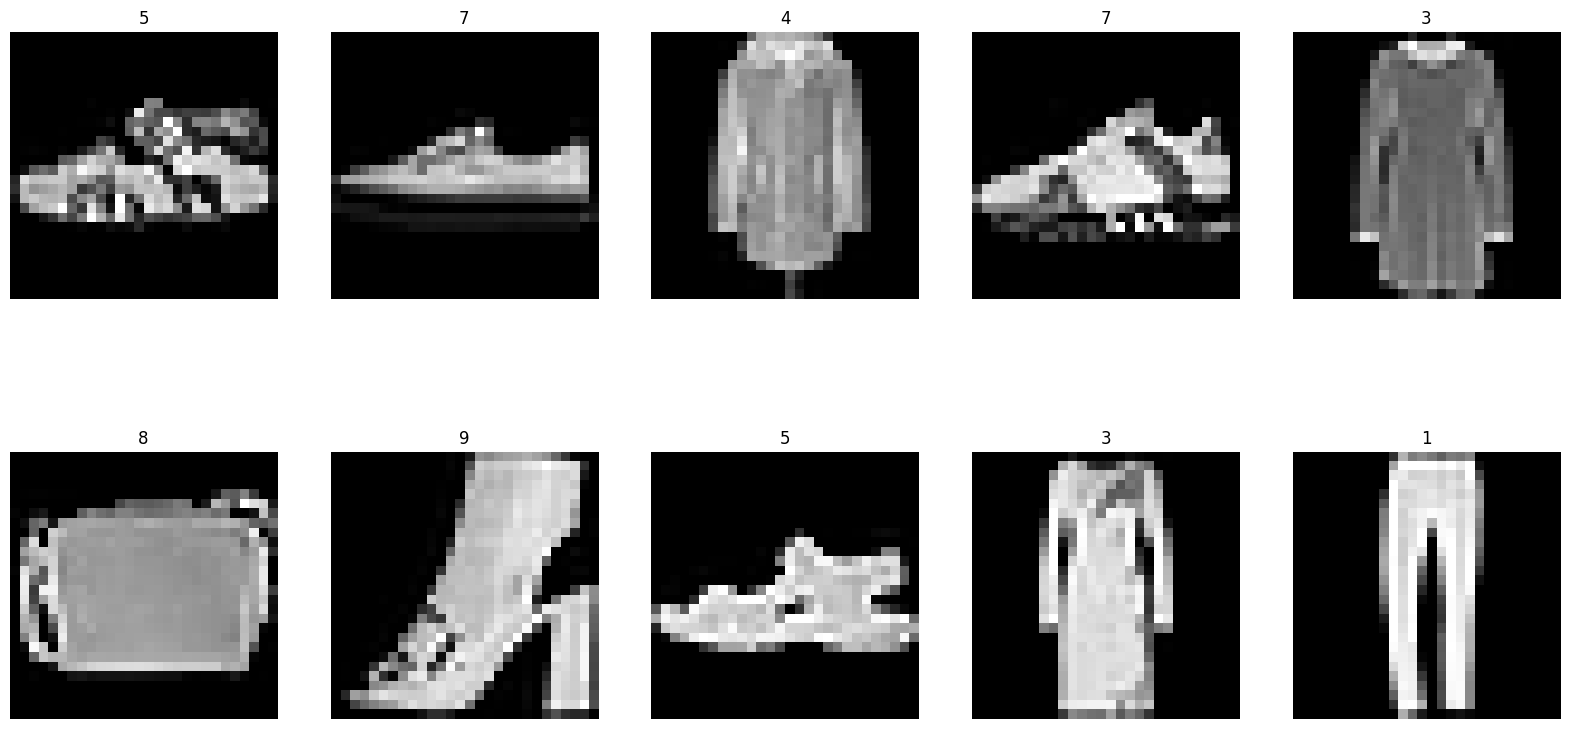

In [2]:
# TODO: загрузите датасет (например, torchvision.datasets.MNIST)
# TODO: создайте train/val/test DataLoader-ы

from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
for ax, img, lbl in zip(axes.flat, images[:10], labels[:10]):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(classes[lbl] if 'classes' in dir() else lbl.item())
    ax.axis('off')
plt.show()



## 2. Формализм прямого прохода и backpropagation

**Задание:** опишите (в markdown, формулами) прямой проход для вашей архитектуры и кратко распишите, как вычисляется ошибка слоя \( \delta^{(l)} \) через цепное правило.

**Вопрос для отчёта:** почему backpropagation имеет вычислительную сложность \(O(P)\) по числу параметров, а не \(O(2P)\), как при наивном численном дифференцировании?


_Ваш ответ (формулы и объяснение):_  
Возьмем архитектуру с двумя скрытыми слоями:
x → FC → BN? → ReLU → Dropout? → logits  
FC - линейная функция, BN? - функция BatchNorm (включаем в завимисости от передаваемого параметра true/false, ReLU - функция активации, Dropout - метод регуляризации, logits - линейный выход логиты, всего L слоев (в рамках лабораторной работы L=3 - два скрытых, один выходной слой)  

FC: z^(l)=W^(l)a^(l−1)+b^(l)

BN: μ = 1 /∣B∣  * ∑Zi (i∈B)  B - батч  
z'^(l) = (z^(l) - μ) / sqrt(σ*σ + e) σ - среднеквадратичная ошибка

ReLu: a^(l) = max(0, z^(l))

Dropout: отдельные нейроны выключаются с вероятностью p и остаются включенным с вероятностью 1-p  

logits z(L) = W(L)a(L−1) + b(L)


Выходной слой.
Считаем δ для последнего слоя. Для softmax + кросс-энтропии это просто разница между предсказанными вероятностями и истинными метками: δ = p − y.
Чтобы получить δ для предыдущего слоя, берём δ следующего слоя, «прогоняем» его через транспонированные веса этого следующего слоя (по сути — умножаем на матрицу весов в обратную сторону) — так ошибка «распределяется» по нейронам предыдущего слоя пропорционально силе связей.
Полученную величину поэлементно умножаем на производную активации этого слоя (для ReLU — это просто маска: где вход был > 0, там градиент проходит, иначе обнуляется). Это и есть применение цепного правила: ошибка проходит через нелинейность.

Backpropagation использует правило цепного разложения и переиспользует промежуточные величины. радиенты всех параметров «делят» одни и те же промежуточные величины
δ(l) — каждое вычисляется один раз и используется для всех параметров слоя.Наивное дифференцирование так не умеет: для каждого оно заново проходит всю сеть.

## 3. Базовая архитектура сети

In [3]:
# TODO: определите класс простого MLP (2-3 полносвязных слоя)
# Параметризуйте модель так, чтобы можно было легко включать/выключать dropout и batchnorm

class SimpleMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, num_classes=10,
                 use_dropout=False, use_batchnorm=False, dropout_p=0.5):
        super().__init__()
        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm


        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim) if use_batchnorm else nn.Identity()
        self.drop1 = nn.Dropout(dropout_p) if use_dropout else nn.Identity()


        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim) if use_batchnorm else nn.Identity()
        self.drop2 = nn.Dropout(dropout_p) if use_dropout else nn.Identity()


        self.fc3 = nn.Linear(hidden_dim, num_classes)

        self.act = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act(x)
        x = self.drop2(x)

        x = self.fc3(x)
        return x


In [4]:
# TODO: напишите универсальные функции train_epoch(model, loader, optimizer, criterion, device)
# и evaluate(model, loader, criterion, device), возвращающие loss и accuracy

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        running_loss += loss.item() * batch_size
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += batch_size

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        batch_size = y.size(0)
        running_loss += loss.item() * batch_size
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += batch_size

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc


## 4. Серия A. Сравнение оптимизаторов

**Задание:** обучите одну и ту же архитектуру (без дополнительной регуляризации) со следующими оптимизаторами:
- SGD;
- SGD + Momentum (momentum=0.9);
- Adam.

Для каждого варианта зафиксируйте одинаковое число эпох и одинаковый learning rate (или обоснуйте отличие).


In [5]:
# TODO: обучите модель с оптимизатором SGD
# Сохраните историю train/test loss и accuracy по эпохам
model_sgd = SimpleMLP()
optimizer = torch.optim.SGD(
    model_sgd.parameters(),
    lr=0.01,
    weight_decay=5e-4,
)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

criterion = nn.CrossEntropyLoss()
num_epochs = 20
history_sgd = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train_epoch(model_sgd, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model_sgd, test_loader, criterion, device)

    history_sgd["train_loss"].append(tr_loss)
    history_sgd["test_loss"].append(va_loss)
    history_sgd["train_acc"].append(tr_acc)
    history_sgd["test_acc"].append(va_acc)

    print(f"Epoch {epoch:2d} | lr {optimizer.param_groups[0]['lr']:.4f} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"test  loss {va_loss:.4f} acc {va_acc:.4f}")

    scheduler.step()

print(history_sgd)

Epoch  1 | lr 0.0100 | train loss 1.3573 acc 0.5873 | test  loss 0.8219 acc 0.7081
Epoch  2 | lr 0.0100 | train loss 0.7012 acc 0.7507 | test  loss 0.6468 acc 0.7727
Epoch  3 | lr 0.0100 | train loss 0.5853 acc 0.7982 | test  loss 0.5753 acc 0.7994
Epoch  4 | lr 0.0100 | train loss 0.5282 acc 0.8173 | test  loss 0.5545 acc 0.8066
Epoch  5 | lr 0.0100 | train loss 0.4962 acc 0.8265 | test  loss 0.5205 acc 0.8102
Epoch  6 | lr 0.0100 | train loss 0.4756 acc 0.8333 | test  loss 0.5006 acc 0.8200
Epoch  7 | lr 0.0100 | train loss 0.4595 acc 0.8394 | test  loss 0.4820 acc 0.8290
Epoch  8 | lr 0.0100 | train loss 0.4480 acc 0.8430 | test  loss 0.4919 acc 0.8230
Epoch  9 | lr 0.0100 | train loss 0.4368 acc 0.8484 | test  loss 0.4701 acc 0.8339
Epoch 10 | lr 0.0100 | train loss 0.4273 acc 0.8521 | test  loss 0.4815 acc 0.8271
Epoch 11 | lr 0.0050 | train loss 0.4146 acc 0.8563 | test  loss 0.4482 acc 0.8417
Epoch 12 | lr 0.0050 | train loss 0.4099 acc 0.8577 | test  loss 0.4433 acc 0.8432
Epoc

In [6]:
df = pd.DataFrame(history_sgd)
df.index = df.index + 1
df.index.name = "epoch"
df = df.round(4)

df.style.format("{:.4f}").background_gradient()

,train_loss,test_loss,train_acc,test_acc
epoch,,,,
1,1.3573,0.8219,0.5873,0.7081
2,0.7012,0.6468,0.7507,0.7727
3,0.5853,0.5753,0.7982,0.7994
4,0.5282,0.5545,0.8173,0.8066
5,0.4962,0.5205,0.8265,0.8102
6,0.4756,0.5006,0.8333,0.8200
7,0.4595,0.4820,0.8394,0.8290
8,0.4480,0.4919,0.8430,0.8230
9,0.4368,0.4701,0.8484,0.8339


In [7]:
# TODO: обучите модель с оптимизатором SGD + Momentum
model_sgd_momentum = SimpleMLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model_sgd_momentum.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=5e-4,
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
num_epochs = 20
history_sgd_momentum = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train_epoch(model_sgd_momentum, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model_sgd_momentum, test_loader, criterion, device)

    history_sgd_momentum["train_loss"].append(tr_loss)
    history_sgd_momentum["test_loss"].append(va_loss)
    history_sgd_momentum["train_acc"].append(tr_acc)
    history_sgd_momentum["test_acc"].append(va_acc)

    print(f"Epoch {epoch:2d} | lr {optimizer.param_groups[0]['lr']:.4f} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"test  loss {va_loss:.4f} acc {va_acc:.4f}")

    scheduler.step()

Epoch  1 | lr 0.0100 | train loss 0.6744 acc 0.7619 | test  loss 0.4868 acc 0.8284
Epoch  2 | lr 0.0100 | train loss 0.4301 acc 0.8460 | test  loss 0.4281 acc 0.8465
Epoch  3 | lr 0.0100 | train loss 0.3838 acc 0.8622 | test  loss 0.4315 acc 0.8438
Epoch  4 | lr 0.0100 | train loss 0.3562 acc 0.8703 | test  loss 0.3983 acc 0.8572
Epoch  5 | lr 0.0100 | train loss 0.3372 acc 0.8772 | test  loss 0.3640 acc 0.8696
Epoch  6 | lr 0.0100 | train loss 0.3229 acc 0.8815 | test  loss 0.3610 acc 0.8687
Epoch  7 | lr 0.0100 | train loss 0.3107 acc 0.8857 | test  loss 0.3549 acc 0.8724
Epoch  8 | lr 0.0100 | train loss 0.3016 acc 0.8889 | test  loss 0.3526 acc 0.8713
Epoch  9 | lr 0.0100 | train loss 0.2917 acc 0.8926 | test  loss 0.3424 acc 0.8766
Epoch 10 | lr 0.0100 | train loss 0.2821 acc 0.8965 | test  loss 0.3476 acc 0.8738
Epoch 11 | lr 0.0050 | train loss 0.2556 acc 0.9068 | test  loss 0.3355 acc 0.8793
Epoch 12 | lr 0.0050 | train loss 0.2519 acc 0.9076 | test  loss 0.3397 acc 0.8761
Epoc

In [8]:
df = pd.DataFrame(history_sgd_momentum)
df.index = df.index + 1
df.index.name = "epoch"

df.style.format("{:.4f}").background_gradient()

,train_loss,test_loss,train_acc,test_acc
epoch,,,,
1,0.6744,0.4868,0.7619,0.8284
2,0.4301,0.4281,0.8460,0.8465
3,0.3838,0.4315,0.8622,0.8438
4,0.3562,0.3983,0.8703,0.8572
5,0.3372,0.3640,0.8772,0.8696
6,0.3229,0.3610,0.8815,0.8687
7,0.3107,0.3549,0.8857,0.8724
8,0.3016,0.3526,0.8889,0.8713
9,0.2917,0.3424,0.8926,0.8766


In [9]:
# TODO: обучите модель с оптимизатором Adam
model_adam = SimpleMLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model_adam.parameters(),
    lr=1e-3,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=0.0,
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
num_epochs = 20
history_adam = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train_epoch(model_adam, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model_adam, test_loader, criterion, device)

    history_adam["train_loss"].append(tr_loss)
    history_adam["test_loss"].append(va_loss)
    history_adam["train_acc"].append(tr_acc)
    history_adam["test_acc"].append(va_acc)

    print(f"Epoch {epoch:2d} | lr {optimizer.param_groups[0]['lr']:.4f} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"test  loss {va_loss:.4f} acc {va_acc:.4f}")

    scheduler.step()

Epoch  1 | lr 0.0010 | train loss 0.5157 acc 0.8135 | test  loss 0.4167 acc 0.8501
Epoch  2 | lr 0.0010 | train loss 0.3660 acc 0.8653 | test  loss 0.3928 acc 0.8563
Epoch  3 | lr 0.0010 | train loss 0.3258 acc 0.8794 | test  loss 0.3537 acc 0.8690
Epoch  4 | lr 0.0010 | train loss 0.3036 acc 0.8863 | test  loss 0.3484 acc 0.8753
Epoch  5 | lr 0.0010 | train loss 0.2840 acc 0.8939 | test  loss 0.3308 acc 0.8791
Epoch  6 | lr 0.0010 | train loss 0.2686 acc 0.8995 | test  loss 0.3407 acc 0.8789
Epoch  7 | lr 0.0010 | train loss 0.2530 acc 0.9045 | test  loss 0.3351 acc 0.8796
Epoch  8 | lr 0.0010 | train loss 0.2402 acc 0.9094 | test  loss 0.3335 acc 0.8844
Epoch  9 | lr 0.0010 | train loss 0.2334 acc 0.9114 | test  loss 0.3390 acc 0.8834
Epoch 10 | lr 0.0010 | train loss 0.2208 acc 0.9159 | test  loss 0.3327 acc 0.8865
Epoch 11 | lr 0.0005 | train loss 0.1860 acc 0.9288 | test  loss 0.3242 acc 0.8921
Epoch 12 | lr 0.0005 | train loss 0.1755 acc 0.9325 | test  loss 0.3192 acc 0.8932
Epoc

In [10]:
df = pd.DataFrame(history_adam)
df.index = df.index + 1
df.index.name = "epoch"

df.style.format("{:.4f}").background_gradient()

,train_loss,test_loss,train_acc,test_acc
epoch,,,,
1,0.5157,0.4167,0.8135,0.8501
2,0.3660,0.3928,0.8653,0.8563
3,0.3258,0.3537,0.8794,0.8690
4,0.3036,0.3484,0.8863,0.8753
5,0.2840,0.3308,0.8939,0.8791
6,0.2686,0.3407,0.8995,0.8789
7,0.2530,0.3351,0.9045,0.8796
8,0.2402,0.3335,0.9094,0.8844
9,0.2334,0.3390,0.9114,0.8834


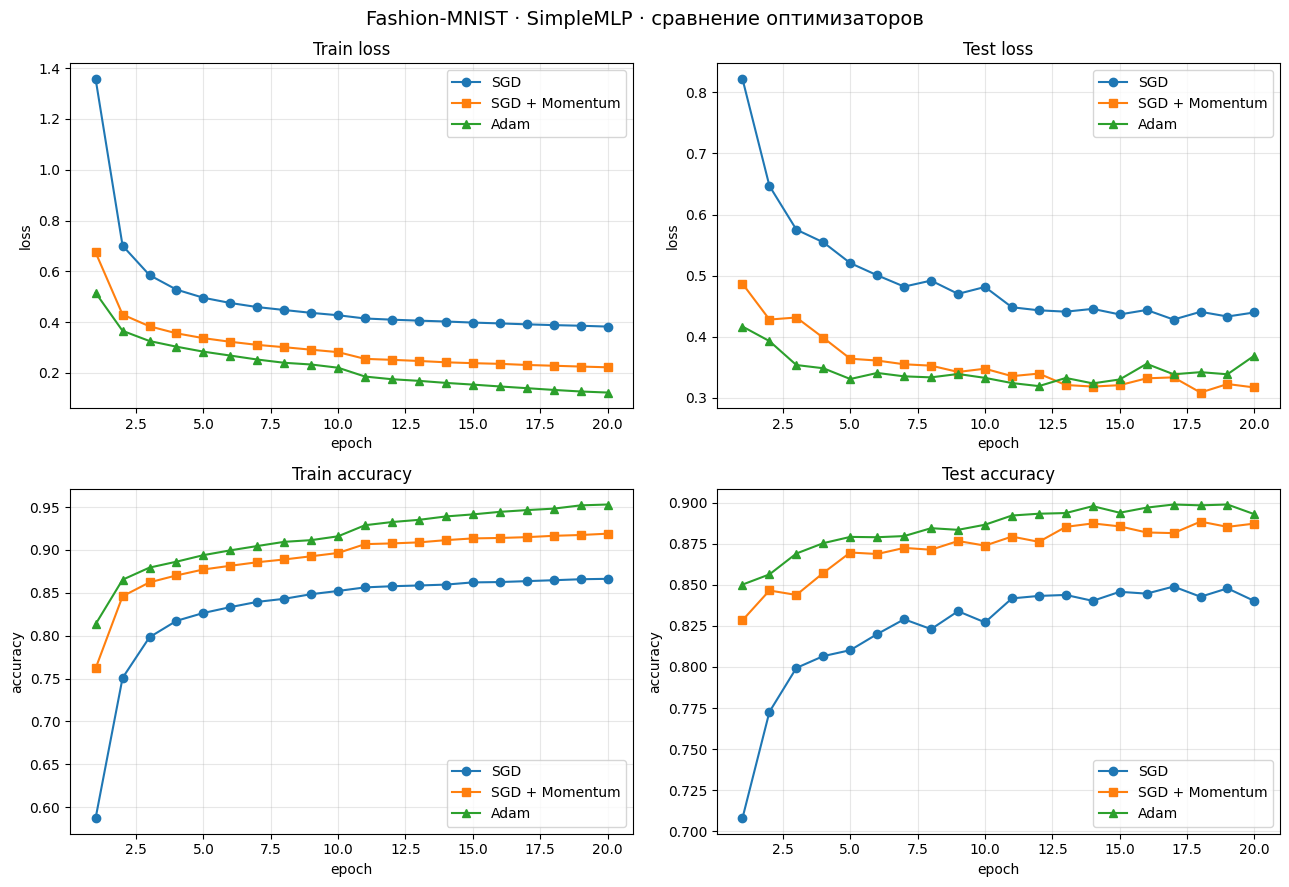

In [11]:
# TODO: постройте графики train/test loss и train/test accuracy для всех трёх оптимизаторов
# Используйте единый график с несколькими линиями для удобного сравнения
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
epochs = range(1, len(history_sgd["train_loss"]) + 1)

# --- Train loss ---
axes[0, 0].plot(epochs, history_sgd["train_loss"],          'o-', label="SGD")
axes[0, 0].plot(epochs, history_sgd_momentum["train_loss"], 's-', label="SGD + Momentum")
axes[0, 0].plot(epochs, history_adam["train_loss"],         '^-', label="Adam")
axes[0, 0].set_title("Train loss")
axes[0, 0].set_xlabel("epoch"); axes[0, 0].set_ylabel("loss")
axes[0, 0].grid(True, alpha=0.3); axes[0, 0].legend()

# --- Test loss ---
axes[0, 1].plot(epochs, history_sgd["test_loss"],          'o-', label="SGD")
axes[0, 1].plot(epochs, history_sgd_momentum["test_loss"], 's-', label="SGD + Momentum")
axes[0, 1].plot(epochs, history_adam["test_loss"],         '^-', label="Adam")
axes[0, 1].set_title("Test loss")
axes[0, 1].set_xlabel("epoch"); axes[0, 1].set_ylabel("loss")
axes[0, 1].grid(True, alpha=0.3); axes[0, 1].legend()

# --- Train accuracy ---
axes[1, 0].plot(epochs, history_sgd["train_acc"],          'o-', label="SGD")
axes[1, 0].plot(epochs, history_sgd_momentum["train_acc"], 's-', label="SGD + Momentum")
axes[1, 0].plot(epochs, history_adam["train_acc"],         '^-', label="Adam")
axes[1, 0].set_title("Train accuracy")
axes[1, 0].set_xlabel("epoch"); axes[1, 0].set_ylabel("accuracy")
axes[1, 0].grid(True, alpha=0.3); axes[1, 0].legend()

# --- Test accuracy ---
axes[1, 1].plot(epochs, history_sgd["test_acc"],          'o-', label="SGD")
axes[1, 1].plot(epochs, history_sgd_momentum["test_acc"], 's-', label="SGD + Momentum")
axes[1, 1].plot(epochs, history_adam["test_acc"],         '^-', label="Adam")
axes[1, 1].set_title("Test accuracy")
axes[1, 1].set_xlabel("epoch"); axes[1, 1].set_ylabel("accuracy")
axes[1, 1].grid(True, alpha=0.3); axes[1, 1].legend()

plt.suptitle("Fashion-MNIST · SimpleMLP · сравнение оптимизаторов", fontsize=14)
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** какой оптимизатор сходится быстрее? У какого варианта наибольший train/test gap? Согласуется ли это с материалом лекции о связи оптимизатора и геометрии минимума?

_Ваш ответ:_  
Быстрее всех сходится модель с оптимизатором Adam.  
Самый большой гэп у модели с SGD.
Результаты сходятся с материалом лекции о связи оптимизатора и геометрии минимума. Adam - более продвинутый оптимизатор, который больше остальных сглаживает минимум, из-за чего сходимость быстрее и результат обучения модели получается лучше в разрезе метрик accuracy и loss.

## 5. Серия B. Сравнение методов регуляризации

**Задание:** для оптимизатора, выбранного по результатам серии A (или заданного преподавателем), обучите варианты модели:
- без регуляризации (baseline);
- с L2-регуляризацией (weight_decay в оптимизаторе);
- с Dropout;
- с BatchNorm;
- (опционально) с early stopping по валидационному loss.


In [21]:
# TODO: baseline без регуляризации
model_baseline = SimpleMLP()
optimizer = torch.optim.Adam(model_baseline.parameters(), lr=1e-3, weight_decay=0.0)
sheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
criterion = nn.CrossEntropyLoss()
history_baseline = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train_epoch(model_baseline, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model_baseline, test_loader, criterion, device)

    history_baseline["train_loss"].append(tr_loss)
    history_baseline["test_loss"].append(va_loss)
    history_baseline["train_acc"].append(tr_acc)
    history_baseline["test_acc"].append(va_acc)

    print(f"Epoch {epoch:2d} | lr {optimizer.param_groups[0]['lr']:.4f} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"test  loss {va_loss:.4f} acc {va_acc:.4f}")

    scheduler.step()


Epoch  1 | lr 0.0010 | train loss 0.5098 acc 0.8171 | test  loss 0.4118 acc 0.8481
Epoch  2 | lr 0.0010 | train loss 0.3678 acc 0.8659 | test  loss 0.4031 acc 0.8583
Epoch  3 | lr 0.0010 | train loss 0.3267 acc 0.8802 | test  loss 0.3845 acc 0.8577
Epoch  4 | lr 0.0010 | train loss 0.3043 acc 0.8869 | test  loss 0.3533 acc 0.8729
Epoch  5 | lr 0.0010 | train loss 0.2858 acc 0.8940 | test  loss 0.3515 acc 0.8729
Epoch  6 | lr 0.0010 | train loss 0.2724 acc 0.8980 | test  loss 0.3255 acc 0.8832
Epoch  7 | lr 0.0010 | train loss 0.2571 acc 0.9036 | test  loss 0.3418 acc 0.8774
Epoch  8 | lr 0.0010 | train loss 0.2460 acc 0.9069 | test  loss 0.3223 acc 0.8852
Epoch  9 | lr 0.0010 | train loss 0.2351 acc 0.9109 | test  loss 0.3628 acc 0.8776
Epoch 10 | lr 0.0010 | train loss 0.2246 acc 0.9143 | test  loss 0.3570 acc 0.8802
Epoch 11 | lr 0.0010 | train loss 0.2150 acc 0.9193 | test  loss 0.3358 acc 0.8837
Epoch 12 | lr 0.0010 | train loss 0.2051 acc 0.9223 | test  loss 0.3695 acc 0.8802
Epoc

In [13]:
# TODO: L2-регуляризация (weight_decay)
history_l2 = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
model_l2 = SimpleMLP()
optimizer = torch.optim.Adam(model_l2.parameters(), lr=1e-3, weight_decay=1e-4)
sheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
criterion = nn.CrossEntropyLoss()
history_baseline = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train_epoch(model_l2, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model_l2, test_loader, criterion, device)

    history_l2["train_loss"].append(tr_loss)
    history_l2["test_loss"].append(va_loss)
    history_l2["train_acc"].append(tr_acc)
    history_l2["test_acc"].append(va_acc)

    print(f"Epoch {epoch:2d} | lr {optimizer.param_groups[0]['lr']:.4f} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"test  loss {va_loss:.4f} acc {va_acc:.4f}")

    scheduler.step()


Epoch  1 | lr 0.0010 | train loss 0.5157 acc 0.8153 | test  loss 0.4392 acc 0.8363
Epoch  2 | lr 0.0010 | train loss 0.3715 acc 0.8648 | test  loss 0.3813 acc 0.8621
Epoch  3 | lr 0.0010 | train loss 0.3370 acc 0.8752 | test  loss 0.3691 acc 0.8649
Epoch  4 | lr 0.0010 | train loss 0.3136 acc 0.8841 | test  loss 0.3617 acc 0.8731
Epoch  5 | lr 0.0010 | train loss 0.2956 acc 0.8901 | test  loss 0.3555 acc 0.8709
Epoch  6 | lr 0.0010 | train loss 0.2837 acc 0.8946 | test  loss 0.3761 acc 0.8696
Epoch  7 | lr 0.0010 | train loss 0.2721 acc 0.8976 | test  loss 0.3299 acc 0.8797
Epoch  8 | lr 0.0010 | train loss 0.2615 acc 0.9023 | test  loss 0.3450 acc 0.8726
Epoch  9 | lr 0.0010 | train loss 0.2543 acc 0.9036 | test  loss 0.3204 acc 0.8833
Epoch 10 | lr 0.0010 | train loss 0.2465 acc 0.9074 | test  loss 0.3239 acc 0.8867
Epoch 11 | lr 0.0010 | train loss 0.2391 acc 0.9105 | test  loss 0.3386 acc 0.8763
Epoch 12 | lr 0.0010 | train loss 0.2305 acc 0.9133 | test  loss 0.3160 acc 0.8905
Epoc

In [14]:
# TODO: Dropout
history_dropout = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
model_dropout = SimpleMLP(use_dropout=True)
optimizer = torch.optim.Adam(model_dropout.parameters(), lr=1e-3, weight_decay=0.0)
sheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
criterion = nn.CrossEntropyLoss()
history_baseline = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train_epoch(model_dropout, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model_dropout, test_loader, criterion, device)

    history_dropout["train_loss"].append(tr_loss)
    history_dropout["test_loss"].append(va_loss)
    history_dropout["train_acc"].append(tr_acc)
    history_dropout["test_acc"].append(va_acc)

    print(f"Epoch {epoch:2d} | lr {optimizer.param_groups[0]['lr']:.4f} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"test  loss {va_loss:.4f} acc {va_acc:.4f}")

    scheduler.step()


Epoch  1 | lr 0.0010 | train loss 0.6454 acc 0.7657 | test  loss 0.4569 acc 0.8342
Epoch  2 | lr 0.0010 | train loss 0.4749 acc 0.8283 | test  loss 0.4110 acc 0.8483
Epoch  3 | lr 0.0010 | train loss 0.4415 acc 0.8404 | test  loss 0.3915 acc 0.8601
Epoch  4 | lr 0.0010 | train loss 0.4179 acc 0.8491 | test  loss 0.3903 acc 0.8604
Epoch  5 | lr 0.0010 | train loss 0.4085 acc 0.8519 | test  loss 0.3775 acc 0.8630
Epoch  6 | lr 0.0010 | train loss 0.3924 acc 0.8565 | test  loss 0.3637 acc 0.8670
Epoch  7 | lr 0.0010 | train loss 0.3867 acc 0.8607 | test  loss 0.3668 acc 0.8669
Epoch  8 | lr 0.0010 | train loss 0.3798 acc 0.8609 | test  loss 0.3629 acc 0.8689
Epoch  9 | lr 0.0010 | train loss 0.3702 acc 0.8649 | test  loss 0.3633 acc 0.8659
Epoch 10 | lr 0.0010 | train loss 0.3659 acc 0.8659 | test  loss 0.3557 acc 0.8731
Epoch 11 | lr 0.0010 | train loss 0.3601 acc 0.8685 | test  loss 0.3434 acc 0.8764
Epoch 12 | lr 0.0010 | train loss 0.3565 acc 0.8696 | test  loss 0.3468 acc 0.8787
Epoc

In [15]:
# TODO: BatchNorm
history_batchnorm = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
model_batchnorm = SimpleMLP(use_batchnorm=True)
optimizer = torch.optim.Adam(model_batchnorm.parameters(), lr=1e-3, weight_decay=0.0)
sheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
criterion = nn.CrossEntropyLoss()
history_baseline = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train_epoch(model_batchnorm, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model_batchnorm, test_loader, criterion, device)

    history_batchnorm["train_loss"].append(tr_loss)
    history_batchnorm["test_loss"].append(va_loss)
    history_batchnorm["train_acc"].append(tr_acc)
    history_batchnorm["test_acc"].append(va_acc)

    print(f"Epoch {epoch:2d} | lr {optimizer.param_groups[0]['lr']:.4f} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"test  loss {va_loss:.4f} acc {va_acc:.4f}")

    scheduler.step()

Epoch  1 | lr 0.0010 | train loss 0.4417 acc 0.8410 | test  loss 0.3829 acc 0.8617
Epoch  2 | lr 0.0010 | train loss 0.3356 acc 0.8771 | test  loss 0.3749 acc 0.8642
Epoch  3 | lr 0.0010 | train loss 0.2970 acc 0.8893 | test  loss 0.3336 acc 0.8789
Epoch  4 | lr 0.0010 | train loss 0.2725 acc 0.8988 | test  loss 0.3341 acc 0.8772
Epoch  5 | lr 0.0010 | train loss 0.2526 acc 0.9049 | test  loss 0.3183 acc 0.8868
Epoch  6 | lr 0.0010 | train loss 0.2337 acc 0.9113 | test  loss 0.3381 acc 0.8808
Epoch  7 | lr 0.0010 | train loss 0.2165 acc 0.9186 | test  loss 0.3197 acc 0.8879
Epoch  8 | lr 0.0010 | train loss 0.2038 acc 0.9229 | test  loss 0.3137 acc 0.8913
Epoch  9 | lr 0.0010 | train loss 0.1902 acc 0.9280 | test  loss 0.3191 acc 0.8911
Epoch 10 | lr 0.0010 | train loss 0.1787 acc 0.9332 | test  loss 0.3128 acc 0.8940
Epoch 11 | lr 0.0010 | train loss 0.1678 acc 0.9362 | test  loss 0.3225 acc 0.8933
Epoch 12 | lr 0.0010 | train loss 0.1566 acc 0.9404 | test  loss 0.3309 acc 0.8915
Epoc

In [22]:
# TODO: сведите результаты всех вариантов регуляризации в единую таблицу
histories = {
    "Baseline":  history_baseline,
    "L2":        history_l2,
    "Dropout":   history_dropout,
    "BatchNorm": history_batchnorm,
}

results_table = pd.DataFrame([
    {
        "variant":   name,
        "train_acc": h["train_acc"][-1],
        "test_acc":  h["test_acc"][-1],
        "gap":       h["train_acc"][-1] - h["test_acc"][-1],
    }
    for name, h in histories.items()
])
results_table = (results_table
                 .round(4)
                 .reset_index(drop=True))
results_table


,variant,train_acc,test_acc,gap
0,Baseline,0.9434,0.8915,0.0520
1,L2,0.9255,0.8890,0.0365
2,Dropout,0.8780,0.8766,0.0014
3,BatchNorm,0.9629,0.8941,0.0688


**Вопрос для отчёта:** какой метод регуляризации дал наименьший train/test gap? Как это соотносится с идеей о том, что регуляризация смещает оптимизацию к более «плоским» минимумам?

_Ваш ответ:_  
Наименьший train/test gap показала модель с Dropout. Это согласуется с представлением о том, что регуляризация смещает оптимизацию к более плоским минимумам: выключение нейронов заставляет сеть учить избыточные, устойчивые представления, которые не подгоняются под обучающую выборку. В результате ландшафт функции потерь вокруг найденного решения становится более гладким по параметрам и модель лучше обобщает.

## 6. Серия C. Проверка устойчивости к возмущениям входа

**Задание:** для каждой обученной модели (минимум для baseline и лучшего варианта регуляризации из серии B) оцените точность на возмущённых тестовых примерах.

Возьмите 20–50 тестовых примеров и добавьте малое ограниченное по норме возмущение (например, равномерный или гауссовский шум с фиксированной амплитудой $ \epsilon $. Сравните accuracy на чистых и возмущённых данных.


In [112]:
# TODO: реализуйте функцию add_noise(x, epsilon) с ограничением нормы возмущения

def add_noise(x, epsilon=0.1):
  return x + torch.empty_like(x).uniform_(-epsilon, epsilon)


In [117]:
# TODO: рассчитайте accuracy на чистых и возмущённых примерах для baseline и лучшей регуляризованной модели
# Сведите результат в таблицу: variant | clean_accuracy | perturbed_accuracy | drop
def accuracy_on_tensor(model, x, y, device):
    model.eval()
    x, y = x.to(device), y.to(device)
    logits = model(x)
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

x_test_sample, y_test_sample = next(iter(test_loader))
x_test_sample = x_test_sample[:500].clone()
y_test_sample = y_test_sample[:500].clone()
torch.manual_seed(RANDOM_STATE)
x_perturbed = add_noise(x_test_sample)

models = {
    "Baseline (Adam)": model_baseline,   # из серии регуляризации
    "Dropout (Adam)":  model_dropout,    # лучший по gap
    "Baseline (SGD)":  model_sgd,        # SGD-модель
}

rows = []
for name, m in models.items():
    clean_acc = accuracy_on_tensor(m, x_test_sample, y_test_sample, device)
    pert_acc  = accuracy_on_tensor(m, x_perturbed, y_test_sample, device)
    rows.append({
        "variant":            name,
        "clean_accuracy":     clean_acc,
        "perturbed_accuracy": pert_acc,
        "drop":               clean_acc - pert_acc,
    })

results_robustness = pd.DataFrame(rows).round(4)
results_robustness

,variant,clean_accuracy,perturbed_accuracy,drop
0,Baseline (Adam),0.8750,0.8594,0.0156
1,Dropout (Adam),0.8906,0.8750,0.0156
2,Baseline (SGD),0.8125,0.8438,-0.0312


**Вопрос для отчёта:** у какой модели (baseline или регуляризованной) точность падает сильнее при одинаковом возмущении? Как это соотносится с идеей о единой структурной проблеме переобучения и adversarial-уязвимости, рассмотренной в лекции?

_Ваш ответ:_
У всех трех примеров примерно одиннаковая устойчивость к возмущениям.
Результат можно объяснить так:  
- Малая выборка (500 элементов, одна ошибка = 0.2%)
- Малое возмущение epsilon = 0.1, которое размазывается на все пиксели входных изображений. Большая часть гасится при усреднении в линейных слоях. Решающая граница практически не сдвигается
- Fashion-MNIST — простая задача. Классы хорошо разделимы, признаки четкие, сеть легко устойчива к слабым возмущениям

## 7. Итоговый вывод

**Вопрос для отчёта:** какая комбинация оптимизатор + регуляризация оказалась наилучшей в вашем эксперименте по совокупности критериев (качество, generalization gap, устойчивость к возмущениям)? Обоснуйте ответ ссылками на полученные графики и таблицы.

_Ваш ответ:_
Наилучшая комбинация для данной задачи: Adam + Dropout. Эта связка показывает лучшие метрики в данной лабораторной работе - больше accuracy и скорость сходимости у Adam, меньший train/test gap у Dropout, чувствительность к малым изменением на уровне погрешности.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже.

### С1. Влияние размера батча
Обучите модель с фиксированным оптимизатором (например, SGD) при разных размерах батча (например, 16, 128, 1024). Сравните итоговый train/test gap и устойчивость к возмущениям. Свяжите результат с идеей о том, что большие батчи уменьшают шум SGD и способствуют более острым минимумам.

### С2. Градиентное возмущение против случайного шума
Реализуйте одношаговое градиентное возмущение входа (по аналогии с FGSM: шаг в направлении знака градиента функции потерь по входу) при той же норме \( \epsilon \), что и в серии C. Сравните падение accuracy при случайном шуме и при градиентном возмущении одинаковой нормы. Объясните, почему градиентное возмущение обычно эффективнее.

### С3. Упрощённая sharpness-aware минимизация (SAM-style)
Реализуйте упрощённую версию SAM: на каждом шаге сделайте вспомогательный шаг в направлении градиента (возмущение параметров \( \epsilon \) с ограничением нормы \( \rho \)), посчитайте градиент в возмущённой точке и обновите исходные параметры по этому градиенту. Сравните итоговую модель с обычным Adam/SGD по generalization gap и устойчивости к возмущениям входа.

### С4. Визуализация ландшафта потерь
Постройте одномерное или двумерное сечение ландшафта функции потерь вокруг найденного минимума (например, добавляя к весам случайные направления с разным масштабом и пересчитывая loss). Сравните "остроту" ландшафта для baseline и для регуляризованной модели, визуализировав это графиком loss vs. amplitude.


In [136]:
# ДЛЯ СИЛЬНЫХ СТУДЕНТОВ
# TODO: реализуйте выбранные задания (С1-С4) здесь
# Задание C1
def make_loader(batch_size):
    return DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True,
    )

def train_with_batch_size(batch_size, num_epochs=50, base_lr=0.01, momentum=0.9,
                          verbose=True,base_bs=128):
    torch.manual_seed(RANDOM_STATE)
    lr = base_lr * batch_size / base_bs
    loader = make_loader(batch_size)
    model = SimpleMLP(use_dropout=False, use_batchnorm=False).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["test_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(va_acc)

        if verbose:
            print(f"  epoch {epoch:2d} | "
                  f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
                  f"test  loss {va_loss:.4f} acc {va_acc:.4f}")

        scheduler.step()

    return model, history

BATCH_SIZES = [16, 128, 1024]

models_bs, histories_bs = {}, {}

for bs in BATCH_SIZES:
    print(f"\n=== batch_size = {bs} ===")
    m, h = train_with_batch_size(bs)
    models_bs[bs] = m
    histories_bs[bs] = h
    print(f"  → final train acc {h['train_acc'][-1]:.4f} | "
          f"test acc {h['test_acc'][-1]:.4f} | "
          f"gap {h['train_acc'][-1] - h['test_acc'][-1]:.4f}")

EPS        = 0.3      # амплитуда L∞-шума на пиксель
N_SAMPLES  = 1000     # сколько тестовых примеров берём
N_SEEDS    = 5        # усредняем по нескольким seed'ам шума

eval_loader = DataLoader(test_dataset, batch_size=N_SAMPLES, shuffle=False)
x_eval, y_eval = next(iter(eval_loader))

rows = []
for bs in BATCH_SIZES:
    m = models_bs[bs]
    h = histories_bs[bs]

    clean_acc = accuracy_on_tensor(m, x_eval, y_eval, device)

    # усредняем perturbed-accuracy по N_SEEDS, чтобы убрать случайность
    pert_accs = []
    for s in range(N_SEEDS):
        gen = torch.Generator(device=x_eval.device).manual_seed(s)
        noise = torch.empty_like(x_eval).uniform_(-EPS, EPS, generator=gen)
        xp = x_eval + noise
        pert_accs.append(accuracy_on_tensor(m, xp, y_eval, device))
    pert_acc = float(np.mean(pert_accs))

    rows.append({
        "batch_size":    bs,
        "train_acc":     h["train_acc"][-1],
        "test_acc":      h["test_acc"][-1],
        "gap":           h["train_acc"][-1] - h["test_acc"][-1],
        "clean_acc":     clean_acc,
        "perturbed_acc": pert_acc,
        "drop":          clean_acc - pert_acc,
        "relative_drop": (clean_acc - pert_acc) / clean_acc,
    })



=== batch_size = 16 ===


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  epoch  1 | train loss 0.7671 acc 0.7368 | test  loss 0.5383 acc 0.8081
  epoch  2 | train loss 0.4734 acc 0.8335 | test  loss 0.4792 acc 0.8322
  epoch  3 | train loss 0.4211 acc 0.8515 | test  loss 0.4477 acc 0.8417
  epoch  4 | train loss 0.3886 acc 0.8616 | test  loss 0.4360 acc 0.8391
  epoch  5 | train loss 0.3655 acc 0.8688 | test  loss 0.4077 acc 0.8544
  epoch  6 | train loss 0.3470 acc 0.8750 | test  loss 0.3774 acc 0.8676
  epoch  7 | train loss 0.3311 acc 0.8796 | test  loss 0.3810 acc 0.8623
  epoch  8 | train loss 0.3190 acc 0.8842 | test  loss 0.3547 acc 0.8737
  epoch  9 | train loss 0.3064 acc 0.8886 | test  loss 0.3635 acc 0.8649
  epoch 10 | train loss 0.2978 acc 0.8911 | test  loss 0.3506 acc 0.8753
  epoch 11 | train loss 0.2736 acc 0.9005 | test  loss 0.3392 acc 0.8784
  epoch 12 | train loss 0.2685 acc 0.9027 | test  loss 0.3553 acc 0.8727
  epoch 13 | train loss 0.2639 acc 0.9044 | test  loss 0.3324 acc 0.8804
  epoch 14 | train loss 0.2588 acc 0.9057 | test  l

In [137]:
results_batchsize = pd.DataFrame(rows).round(4)
summary = results_batchsize[[
    "batch_size", "train_acc", "test_acc", "gap",
    "clean_acc", "perturbed_acc", "relative_drop"
]]
print("\n=== Итог ===")
print(summary.to_string(index=False))


=== Итог ===
 batch_size  train_acc  test_acc    gap  clean_acc  perturbed_acc  relative_drop
         16     0.9399    0.8953 0.0446      0.893         0.8518         0.0461
        128     0.9396    0.8937 0.0459      0.892         0.8512         0.0457
       1024     0.9354    0.8948 0.0406      0.904         0.8596         0.0491


В рамках этой лабораторной работы в результате не особо видна зависимость большой батч -> меньше шум SGD.
Измерения проводились на разных количествах эпох (3, 10, 25 и 50 эпох), с увелечением количества эпох качество модели с 1024 размером батча выросла и сравнялась с 16 и 128. Но нужного результата так и не стало видно - ожидалось увидеть следующую картину: gap должен расти с с batch size, шум SGD должен уменьшаться (relative_drop), острота минимума должна увеличится.  
Такой результат получен из-за особенностей выбранного датасета, неявных признаков и параметров модели.

In [130]:
x_ls, y_ls = next(iter(train_loader))
x_ls = x_ls[:1000].clone()
y_ls = y_ls[:1000].clone()

criterion_eval = nn.CrossEntropyLoss()

def eval_loss(model, x, y, criterion, device, batch_size=512):
    model.eval()
    total, n = 0.0, 0
    for i in range(0, len(x), batch_size):
        xb = x[i:i+batch_size].to(device)
        yb = y[i:i+batch_size].to(device)
        total += criterion(model(xb), yb).item() * len(xb)
        n += len(xb)
    return total / n


def get_filter_normalized_directions(model, n_dirs=2, seed=0):

    gens = [torch.Generator().manual_seed(seed + k) for k in range(n_dirs)]
    directions = [[] for _ in range(n_dirs)]

    for p in model.parameters():
        for k in range(n_dirs):
            d = torch.randn(p.shape, generator=gens[k]).to(p.device)
            d = d / (d.norm() + 1e-12) * p.norm()
            directions[k].append(d)
    return directions


def set_params_along_directions(model, base_params, directions, a1, a2):
    with torch.no_grad():
        for p, base, d1, d2 in zip(model.parameters(), base_params,
                                    directions[0], directions[1]):
            p.copy_(base + a1 * d1 + a2 * d2)


def restore_params(model, base_params):
    with torch.no_grad():
        for p, base in zip(model.parameters(), base_params):
            p.copy_(base)

def loss_landscape_2d(model, x, y, criterion, device,
                      alpha_range=(-1.5, 1.5), n=25, seed=0):
    base_params = [p.detach().clone() for p in model.parameters()]
    directions = get_filter_normalized_directions(model, n_dirs=2, seed=seed)

    alphas = np.linspace(*alpha_range, n)
    Z = np.zeros((n, n))

    for i, a1 in enumerate(alphas):
        for j, a2 in enumerate(alphas):
            set_params_along_directions(model, base_params, directions, a1, a2)
            Z[i, j] = eval_loss(model, x, y, criterion, device)

    restore_params(model, base_params)
    return alphas, Z

N_GRID     = 25
ALPHA_RANGE = (-1.5, 1.5)

alphas, Z_baseline = loss_landscape_2d(
    model_baseline, x_ls, y_ls, criterion_eval, device,
    alpha_range=ALPHA_RANGE, n=N_GRID, seed=0,
)

_, Z_dropout = loss_landscape_2d(
    model_dropout, x_ls, y_ls, criterion_eval, device,
    alpha_range=ALPHA_RANGE, n=N_GRID, seed=0,
)

print(f"Baseline loss range: min={Z_baseline.min():.3f}  max={Z_baseline.max():.3f}")
print(f"Dropout  loss range: min={Z_dropout.min():.3f}  max={Z_dropout.max():.3f}")



Baseline loss range: min=0.095  max=56.015
Dropout  loss range: min=0.249  max=24.923


По полученным результатам можно сделать следующий вывод:
- В регуляризованной модели loss изначально выше, но отноклонение от него сильно меньш (примерно в 100 раз от минимального  
- В Baseline модели минимум меньше, но отклонение от него в 6 раз выше, чем у регуляризованной (в 600 раз против 100 раз)
Такое отклонение явно указывает нам на то, что в baseline модели более острый минимум, чем у модели с dropout

---

## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны обе серии экспериментов (A и B) и минимум базовая проверка устойчивости (серия C).
